# Markov Decision Process (MDP)

### Ransalu Senanayake

In [15]:
import copy
import timeit
import numpy as np
import matplotlib.pyplot as pl
%matplotlib inline
from ipywidgets import interactive
import ipywidgets as widgets

Create the following grid world.

**States:** A 10x10 grid

**Actions:** Up, Down, Left, Right

**Tranistion probabilities:**
* 0.7 in the direction of action
* 0.1 in the three other directions
* The robot bounces back to the same state near edges

**Rewards:**
* (7,8) has a reward +10
* (2,7) has a reward +3
* (4,3) has a reward -5
* (7,3) has a reward -10
* No reward in other states

This example is based on Decision Making Under Uncertainty by M.J. Kochenderfer.

In [16]:
#Let's define MDP paras
def createGrid10World():
    def xy2s(y, x):
        x = max(x, 0)
        y = max(y, 0)
        x = min(x, 9)
        y = min(y, 9)
        out = np.ravel_multi_index(np.array([x,y]), (10,10))
        return out

    def s2xy(s):
        x, y = np.unravel_index(s, (10,10))
        return y, x

    def gridPlot(ax, im, title='', cmap='Blues'):
        pl.imshow(im, interpolation='none', cmap=cmap, origin='lower')
        pl.colorbar()
        ax.set_xticks(np.arange(0, 10, 1));
        ax.set_yticks(np.arange(0, 10, 1));
        ax.set_xticklabels(np.arange(0, 10, 1));
        ax.set_yticklabels(np.arange(0, 10, 1));
        ax.set_xticks(np.arange(-.5, 10, 1), minor=True);
        ax.set_yticks(np.arange(-.5, 10, 1), minor=True);
        ax.grid(which='minor', color='w', linestyle='-', linewidth=1)
        pl.title(title);
        return

    A = ['left', 'right', 'up', 'down']
    S = np.arange(100)
    T = np.zeros((len(S), len(A), len(S)))
    R = np.zeros((len(S), len(A)))
    for s in S:
        x, y = s2xy(s)
        if x == 2 and y == 7:
            R[s, :] = 3
        elif x == 7 and y == 8:
            R[s, :] = 10
        else:
            if x == 7 and y == 3:
                R[s, :] = -10
            elif x == 4 and y == 3:
                R[s, :] = -5
            elif x == 0:
                if y == 0 or y == 9:
                    R[s, :] = -0.2
                else:
                    R[s, :] = -0.1
                R[s, 0] = -0.7
            elif x == 9:
                if y == 0 or y == 9:
                    R[s, :] = -0.2
                else:
                    R[s, :] = -0.1
                R[s, 1] = -0.7
            elif y == 0:
                if x == 0 or x == 9:
                    R[s, :] = -0.2
                else:
                    R[s, :] = -0.1
                R[s, 3] = -0.7
            elif y == 9:
                if x == 0 or x == 9:
                    R[s, :] = -0.2
                else:
                    R[s, :] = -0.1
                R[s, 2] = -0.7

            for a in A:
                if a == 'left':
                    T[s, 0, xy2s(x - 1, y)] += 0.7
                    T[s, 0, xy2s(x + 1, y)] += 0.1
                    T[s, 0, xy2s(x, y - 1)] += 0.1
                    T[s, 0, xy2s(x, y + 1)] += 0.1
                elif a == 'right':
                    T[s, 1, xy2s(x + 1, y)] += 0.7
                    T[s, 1, xy2s(x - 1, y)] += 0.1
                    T[s, 1, xy2s(x, y - 1)] += 0.1
                    T[s, 1, xy2s(x, y + 1)] += 0.1
                elif a == 'up':
                    T[s, 2, xy2s(x, y + 1)] += 0.7
                    T[s, 2, xy2s(x, y - 1)] += 0.1
                    T[s, 2, xy2s(x - 1, y)] += 0.1
                    T[s, 2, xy2s(x + 1, y)] += 0.1
                elif a == 'down':
                    T[s, 3, xy2s(x, y - 1)] += 0.7
                    T[s, 3, xy2s(x, y + 1)] += 0.1
                    T[s, 3, xy2s(x - 1, y)] += 0.1
                    T[s, 3, xy2s(x + 1, y)] += 0.1

    for a, c_x, c_y in [(0,0,0), (0,0,9),(1,9,0),(1,9,9),(2,0,9),(2,9,9),(3,0,0),(3,9,0)]:
        R[xy2s(c_x,c_y),a] = -0.8

    discount = 0.9

    nextStates = {}
    for si in range(len(S)):
        for ai in range(len(A)):
            nextStates[(si,ai)] = np.where((T[si, ai, :] != 0) == True)[0]

    return {'S':S, 'A':A, 'T':T, 'R':R, 'discount':discount, 'nextStates':nextStates, 'gridPlot':gridPlot, 'xy2s':xy2s, 's2xy':s2xy}

In [17]:
class MDP():
    def __init__(self):
        pass

    def inbuilt_init(self, mdp_dict):
        self.S = mdp_dict['S']
        self.A = mdp_dict['A']
        self.T = mdp_dict['T']
        self.R = mdp_dict['R']
        self.discount = mdp_dict['discount']
        self.nextStates = mdp_dict['nextStates']
        self.gridPlot = mdp_dict['gridPlot']
        self.xy2s = mdp_dict['xy2s']
        self.s2xy = mdp_dict['s2xy']

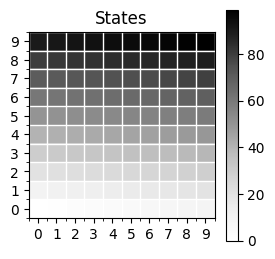

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


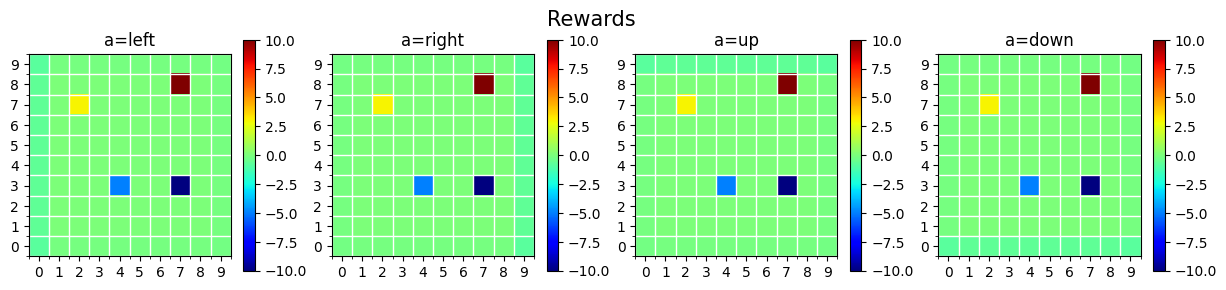

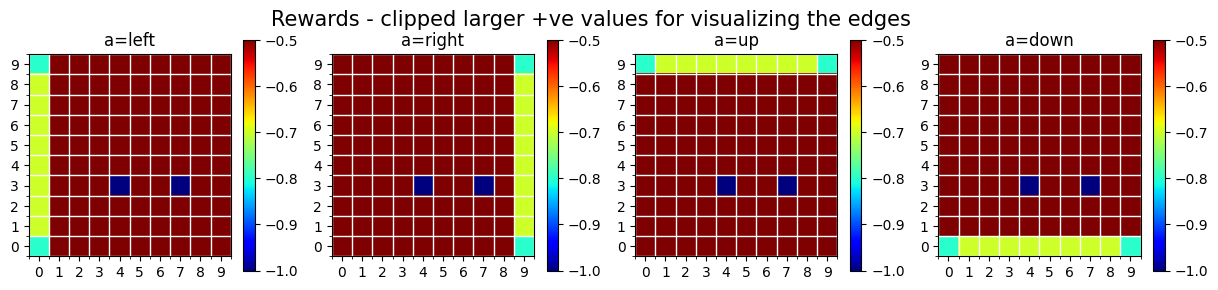

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


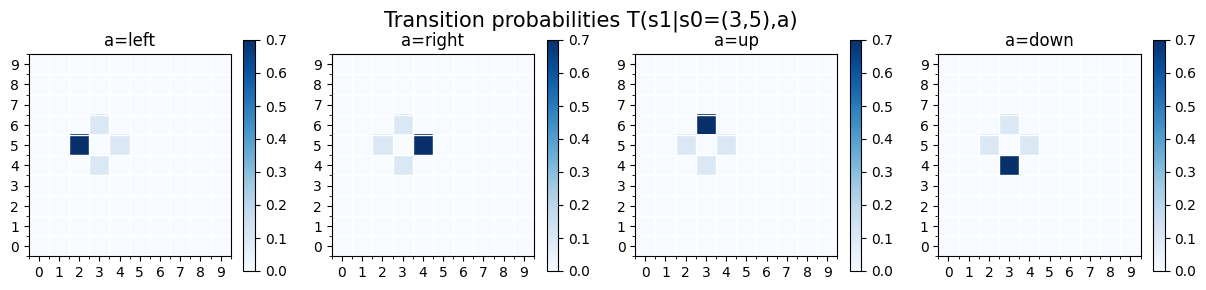

In [18]:
#Define the MDP
mdp = MDP()
mdp.inbuilt_init(mdp_dict=createGrid10World())

#Plot states
pl.figure(figsize=(3,3))
mdp.gridPlot(ax=pl.gca(), im=mdp.S.reshape((10,10)), title='States', cmap='Greys')

#Plot rewards
pl.figure(figsize=(15,3))
pl.suptitle('Rewards', fontsize=15)
for a in range(4):
    pl.subplot(1,4,a+1)
    mdp.gridPlot(ax=pl.gca(), im=mdp.R[:,a].reshape((10,10)), title='a='+mdp.A[a], cmap='jet')
pl.show()

#Plot rewards
pl.figure(figsize=(15,3))
pl.suptitle('Rewards - clipped larger +ve values for visualizing the edges', fontsize=15)
for a in range(4):
    pl.subplot(1,4,a+1)
    mdp.gridPlot(ax=pl.gca(), im=np.clip(mdp.R[:,a].reshape((10,10)), -1, -0.5), title='a='+mdp.A[a], cmap='jet')
pl.show()

#Plot rewards
s0_x, s0_y = 3, 5
s0 = mdp.xy2s(s0_x, s0_y)
pl.figure(figsize=(15,3))
pl.suptitle('Transition probabilities T(s1|s0=({},{}),a)'.format(s0_x, s0_y), fontsize=15)
for a in range(4):
    pl.subplot(1,4,a+1)
    mdp.gridPlot(ax=pl.gca(), im=mdp.T[s0,a,:].reshape((10,10)), title='a='+mdp.A[a], cmap='Blues')
pl.show()

In [19]:
#An interactive plot of transition probabilities
def f(s0_x, s0_y, action):
    a = mdp.A.index(action)
    s0 = mdp.xy2s(int(s0_x), int(s0_y))
    pl.figure(figsize=(6,6))
    title = 'Transition probabilities T(s1|s0=({},{}),a={})'.format(int(s0_x),int(s0_y),action)
    mdp.gridPlot(ax=pl.gca(), im=mdp.T[s0,a,:].reshape((10,10)), title=title, cmap='Blues')
    pl.show()

interactive_plot = interactive(f, s0_x='4', s0_y='5', action=widgets.ToggleButtons(options=['left', 'right', 'up', 'down']))
interactive_plot

interactive(children=(Text(value='4', description='s0_x'), Text(value='5', description='s0_y'), ToggleButtons(…

### 1. Policy evaluation

Computing the utility, U.

$U^\pi_k(s) = R(s, \pi(s)) + \gamma \sum_{s'} T(s' \mid s, \pi(s))U^\pi_{k-1}(s')$

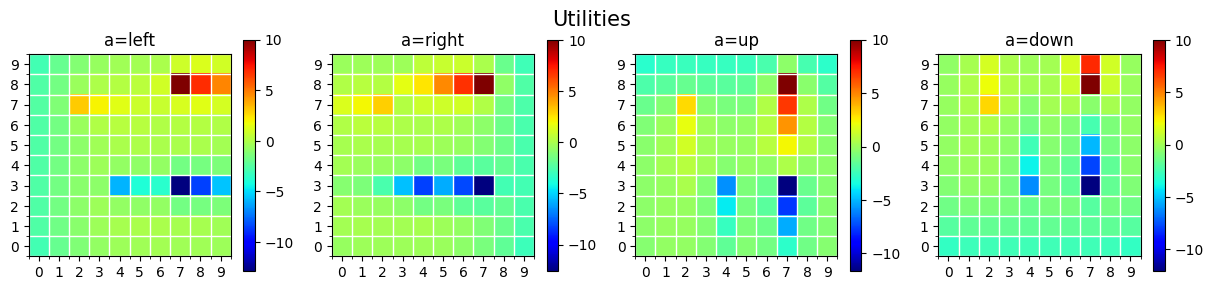

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [20]:
def iterativePolicyEvaluation(mdp, policy, numIterations=10, theta=1e-6):
    U = np.zeros(len(mdp.S))

    # normalize policy: if int → same action for all states
    if isinstance(policy, (int, np.integer)):
        pi = np.ones(len(mdp.S), dtype=int) * int(policy)
    else:
        pi = np.array(policy, dtype=int)

    for t in range(numIterations):
        delta = 0.0
        U_old = U.copy()
        for s in mdp.S:
            a = pi[s]
            next_states = mdp.nextStates[(s, a)]
            probs = mdp.T[s, a, next_states]
            expected_U = np.dot(probs, U_old[next_states])
            new_U = mdp.R[s, a] + mdp.discount * expected_U
            delta = max(delta, abs(new_U - U[s]))
            U[s] = new_U
        if delta < theta:
            break
    return U

numIterations = 5
pl.figure(figsize=(15,3))
pl.suptitle('Utilities', fontsize=15)
for a in range(4):
    pl.subplot(1,4,a+1)
    U = iterativePolicyEvaluation(mdp=mdp, policy=a, numIterations=numIterations)
    mdp.gridPlot(ax=pl.gca(), im=U.reshape(10,10), title='a='+mdp.A[a], cmap='jet')
pl.show()
#print(np.round(U.reshape(10,10),3))

In [21]:
def f(action, numIter=1):
    U = iterativePolicyEvaluation(mdp, policy=mdp.A.index(action), numIterations=numIter)
    pl.figure(figsize=(3,3))
    mdp.gridPlot(ax=pl.gca(), im=U.reshape(10,10), title='Utility', cmap='jet')
    pl.show()

interactive_plot = interactive(f, action=widgets.ToggleButtons(options=['left', 'right', 'up', 'down']),
                               numIter=widgets.IntSlider(min=0, max=20, step=1, value=0))
interactive_plot

interactive(children=(ToggleButtons(description='action', options=('left', 'right', 'up', 'down'), value='left…

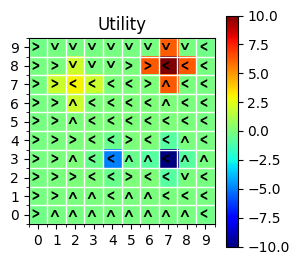

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [22]:
#Value iteration
def valueIteration(mdp, numIterations=1, theta=1e-6):
    U = np.zeros(len(mdp.S))
    for t in range(numIterations):
        delta = 0.0
        U_old = U.copy()
        for s in mdp.S:
            action_values = np.zeros(len(mdp.A))
            for a in range(len(mdp.A)):
                next_states = mdp.nextStates[(s, a)]
                probs = mdp.T[s, a, next_states]
                expected_U = np.dot(probs, U_old[next_states])
                action_values[a] = mdp.R[s, a] + mdp.discount * expected_U
            new_U = np.max(action_values)
            delta = max(delta, abs(new_U - U[s]))
            U[s] = new_U
        if delta < theta:
            break
    return U


def policyExtration(mdp, U):
    policy = np.zeros(len(mdp.S), dtype=int)
    for s in mdp.S:
        action_values = np.zeros(len(mdp.A))
        for a in range(len(mdp.A)):
            next_states = mdp.nextStates[(s, a)]
            probs = mdp.T[s, a, next_states]
            expected_U = np.dot(probs, U[next_states])
            action_values[a] = mdp.R[s, a] + mdp.discount * expected_U
        policy[s] = int(np.argmax(action_values))
    return policy


U = valueIteration(mdp, numIterations=2)
policy = policyExtration(mdp, U=U)
pl.figure(figsize=(3,3))
mdp.gridPlot(ax=pl.gca(), im=U.reshape(10,10), title='Utility', cmap='jet')
for s in range(100):
    x, y = mdp.s2xy(s)
    if policy[s] == 0:
        m='\u02C2'
    elif policy[s] == 1:
        m='\u02C3'
    elif policy[s] == 2:
        m='\u02C4'
    elif policy[s] == 3:
        m='\u02C5'
    pl.text(x-0.5,y-1,m,color='k',size=20)
pl.show()

In [23]:
def f(numIter=1):
    start_time = timeit.default_timer()
    U = valueIteration(mdp, numIterations=numIter)
    policy = policyExtration(mdp, U=U)
    elapsed = timeit.default_timer() - start_time
    print('time=', np.round(elapsed*1000,2))
    pl.figure(figsize=(3,3))
    mdp.gridPlot(ax=pl.gca(), im=U.reshape(10,10), title='Utility', cmap='jet')
    for s in range(100):
        x, y = mdp.s2xy(s)
        if policy[s] == 0:
            m='\u02C2'
        elif policy[s] == 1:
            m='\u02C3'
        elif policy[s] == 2:
            m='\u02C4'
        elif policy[s] == 3:
            m='\u02C5'
        pl.text(x-0.5,y-1,m,color='k',size=20)
    pl.show()

interactive_plot = interactive(f, numIter=widgets.IntSlider(min=0, max=20, step=1, value=0))
interactive_plot

interactive(children=(IntSlider(value=0, description='numIter', max=20), Output()), _dom_classes=('widget-inte…

### 2. Policy iteration

Policy evaluation can be used in policy iteration:
1. Given the current policy, compute U
2. Using U, compute a new policy

In [24]:
def policyIteration(mdp, numIterations=1, evalTheta=1e-6, evalMaxIter=1000):
    U_pi_k = np.zeros(len(mdp.S)) # initial values
    pi_k = np.random.randint(low=0, high=len(mdp.A), size=len(mdp.S), dtype=int) # initial random policy
    pi_kp1 = pi_k.copy()

    for t in range(numIterations):
        # --- Policy evaluation ---
        U_pi_k = iterativePolicyEvaluation(mdp, policy=pi_k, numIterations=evalMaxIter, theta=evalTheta)

        # --- Policy improvement ---
        policy_stable = True
        for s in mdp.S:
            old_action = pi_k[s]
            action_values = np.zeros(len(mdp.A))
            for a in range(len(mdp.A)):
                next_states = mdp.nextStates[(s, a)]
                probs = mdp.T[s, a, next_states]
                expected_U = np.dot(probs, U_pi_k[next_states])
                action_values[a] = mdp.R[s, a] + mdp.discount * expected_U
            best_action = int(np.argmax(action_values))
            pi_kp1[s] = best_action
            if best_action != old_action:
                policy_stable = False

        pi_k = pi_kp1.copy()
        if policy_stable:
            break

    return U_pi_k, pi_kp1


U_pi_k, pi_kp1 = policyIteration(mdp, numIterations=2)

In [25]:
def f(numIter=1):
    start_time = timeit.default_timer()
    # code you want to evaluate
    value, policy = policyIteration(mdp, numIterations=numIter)
    elapsed = timeit.default_timer() - start_time
    print('time=', np.round(elapsed*1000,2))
    pl.figure(figsize=(3,3))
    mdp.gridPlot(ax=pl.gca(), im=value.reshape(10,10), title='Utility', cmap='jet')
    for s in range(100):
        x, y = mdp.s2xy(s)
        if policy[s] == 0:
            m='\u02C2'
        elif policy[s] == 1:
            m='\u02C3'
        elif policy[s] == 2:
            m='\u02C4'
        elif policy[s] == 3:
            m='\u02C5'
        pl.text(x-0.5,y-1,m,color='k',size=20)
    pl.show()

interactive_plot = interactive(f, numIter=widgets.IntSlider(min=0, max=20, step=1, value=0))
interactive_plot

interactive(children=(IntSlider(value=0, description='numIter', max=20), Output()), _dom_classes=('widget-inte…

Execution Time (Value Iteration): 0.000365 seconds
Execution Time (Q-Learning): 9.518719 seconds


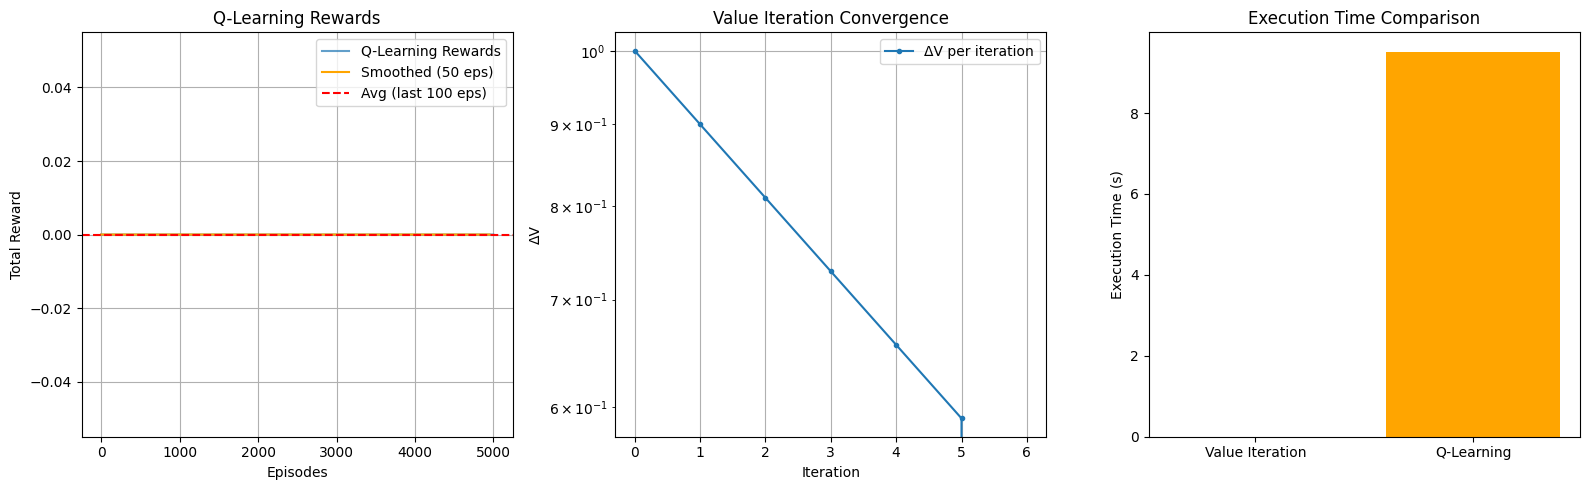

In [32]:

import numpy as np
import gym
import time
import matplotlib.pyplot as plt

# Patch for old numpy bool8 issue
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

# ---------- Q-Learning ----------
def q_learning(env, episodes=5000, alpha=0.1, gamma=0.9, epsilon=0.1):
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    Q = np.zeros((n_states, n_actions))
    rewards = []
    start_time = time.time()

    for ep in range(episodes):
        state = env.reset()
        if isinstance(state, tuple):
            state = state[0]
        total_reward = 0
        done = False
        while not done:
            # ε-greedy action selection
            if np.random.rand() < epsilon:
                action = np.random.choice(n_actions)
            else:
                action = np.argmax(Q[state])

            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            best_next_action = np.argmax(Q[next_state])
            Q[state, action] += alpha * (reward + gamma * Q[next_state, best_next_action] - Q[state, action])
            state = next_state
            total_reward += reward

        rewards.append(total_reward)

    exec_time = time.time() - start_time
    return Q, rewards, exec_time



def value_iteration(env, gamma=0.9, theta=1e-6):
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    V = np.zeros(n_states)
    deltas = []
    start_time = time.time()


    P = getattr(env.unwrapped, "P", None)
    if P is None:
        raise ValueError("Value Iteration requires a discrete environment with env.P attribute.")

    while True:
        delta = 0
        for s in range(n_states):
            v = V[s]
            q_values = []
            for a in range(n_actions):
                q = 0
                for prob, next_state, reward, done in P[s][a]:
                    q += prob * (reward + gamma * V[next_state])
                q_values.append(q)
            V[s] = max(q_values)
            delta = max(delta, abs(v - V[s]))
        deltas.append(delta)
        if delta < theta:
            break

    exec_time = time.time() - start_time
    return V, deltas, exec_time


# ---------- Environment ----------
env = gym.make("FrozenLake-v1", is_slippery=False, new_step_api=True)

# Run Q-Learning
Q_table, q_rewards, time_q = q_learning(env, episodes=5000)
q_rewards = np.array(q_rewards)

# Run Value Iteration
V_vi, deltas_vi, time_vi = value_iteration(env)

print(f"Execution Time (Value Iteration): {time_vi:.6f} seconds")
print(f"Execution Time (Q-Learning): {time_q:.6f} seconds")

# ---------- Plotting ----------
plt.figure(figsize=(16,5))

# 1. Q-Learning Rewards
plt.subplot(1,3,1)
plt.plot(q_rewards, label="Q-Learning Rewards", alpha=0.7)
plt.plot(np.convolve(q_rewards, np.ones(50)/50, mode='valid'), label="Smoothed (50 eps)", color='orange')
plt.axhline(np.mean(q_rewards[-100:]), color='r', linestyle='--', label="Avg (last 100 eps)")
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Q-Learning Rewards")
plt.legend()
plt.grid(True)

# 2. Value Iteration Convergence
plt.subplot(1,3,2)
plt.plot(deltas_vi, marker='o', markersize=3, label="ΔV per iteration")
plt.xlabel("Iteration")
plt.ylabel("ΔV")
plt.title("Value Iteration Convergence")
plt.yscale("log")
plt.legend()
plt.grid(True)

# 3. Execution Time Comparison
plt.subplot(1,3,3)
plt.bar(["Value Iteration", "Q-Learning"], [time_vi, time_q], color=['blue','orange'])
plt.ylabel("Execution Time (s)")
plt.title("Execution Time Comparison")

plt.tight_layout()
plt.show()


Question 1 -

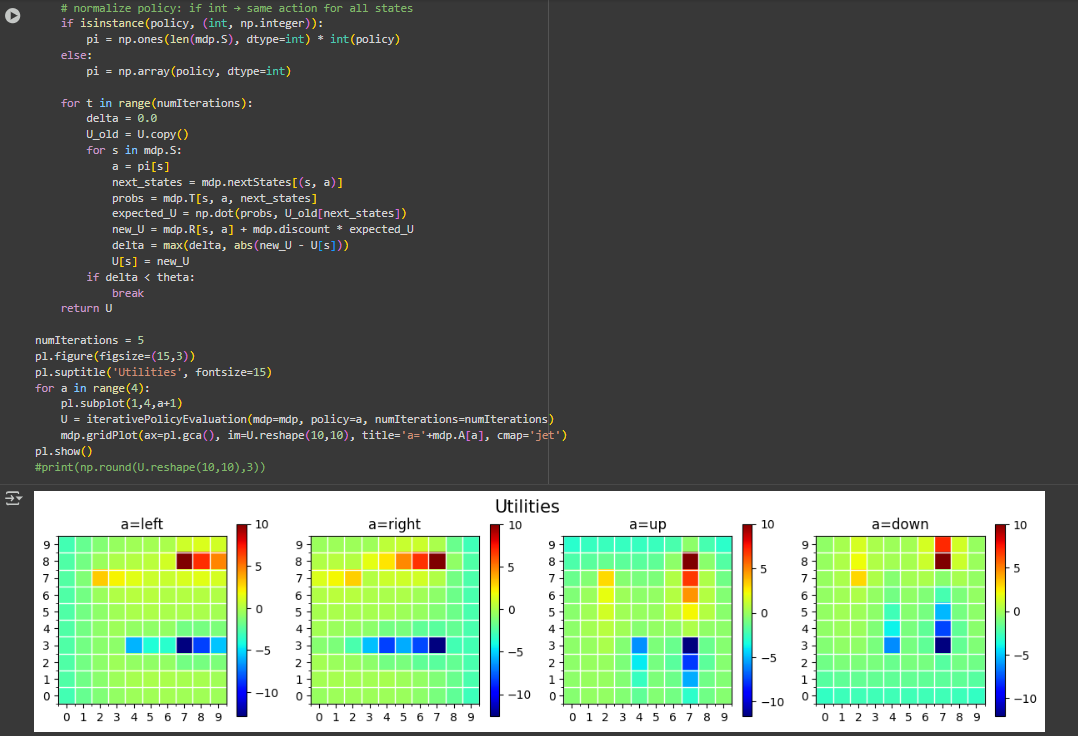

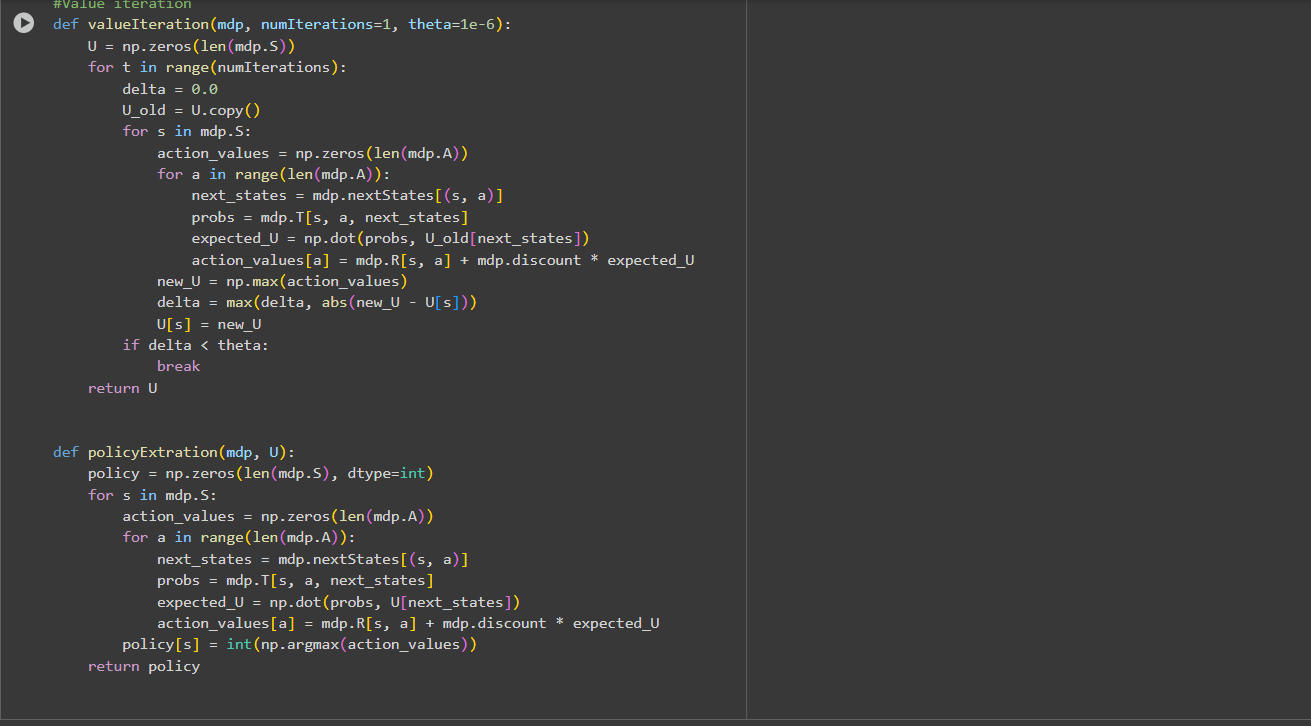

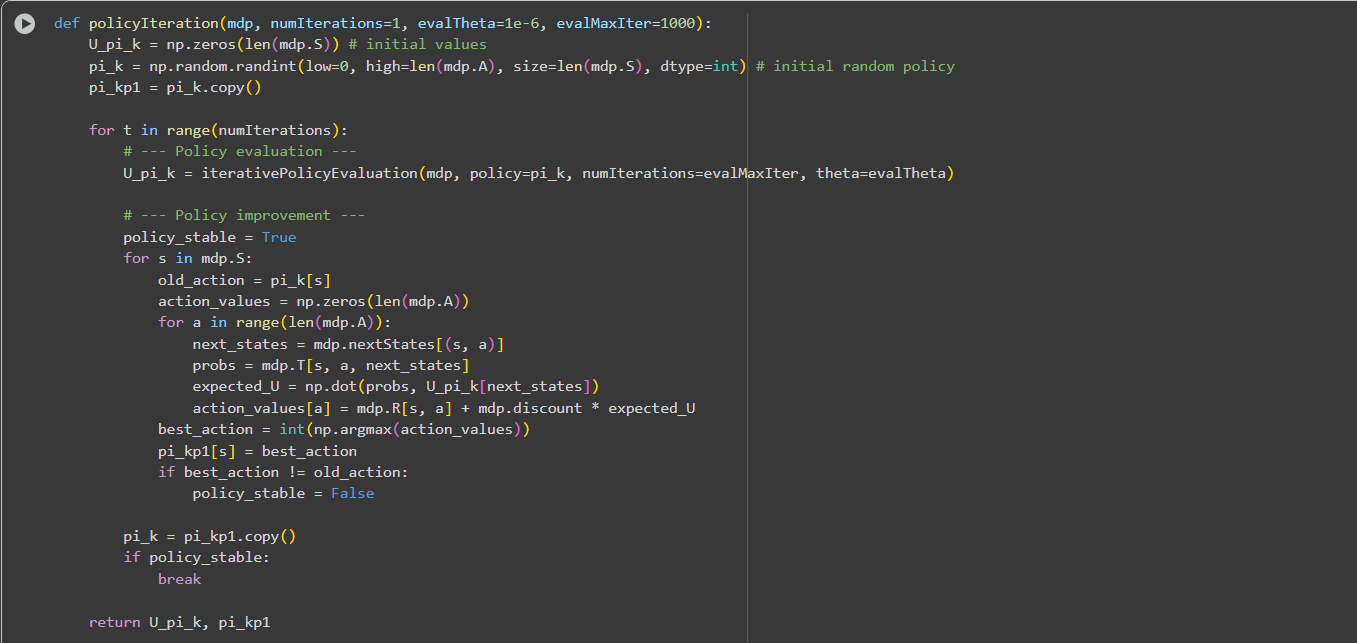